# **Calsificador de emociones de perros**

En este modelo tiene como propósito generar un clasificador de las emociones de los perros, para esto se todo un dataset de kaggle con multiples imágenes de diferentes emociones:
- [Dog Emotion](https://www.kaggle.com/datasets/danielshanbalico/dog-emotion/data)

Este dataset tiene la siguiente información, tiene un total de 4 diferentes emociones siendo las más básicas:
- angry
- happy
- relaxed
- sad

La estructura de los datos es la siguiente:

```
angry/
    dog_angry.jpg
    ...
happy/
    dog_happy.jpg
    ...
relaxed/
    dog_relaxed.jpg
    ...
sad/
    dog_sad.jpg
    ...
```

Como vemos estan separadas por carpetas sin embargo no por carpetas para el entrenamiento del modelo asi que para ello se realizara un split de la imágenes para generar estas carpetas, otro elemento importante es que todas las carpetas cuentan con un total de 1000 imágenes por lo que llega a ser muy util pues están balanceadas.
Con eso estos fueron los pasos para entrenar el modelo:

## **1. Importacion de librerias**

Durante la ejecucíon del programa se utilizaron multiples librerias, asi que para poder centralizar más se decidio poner todas al principio del código para saber que librerias se usan para este código

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import shutil, random
from pathlib import Path

from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.applications import VGG16, EfficientNetV2B0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

from google.colab import drive

## **2. Cargar las Imágenes**

Lo primero que se realizo para la ejecucion del modelo es montar el drive al collab, esto para tener acceso a las imágenes.

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


Una vez montado el drive se navega a la carpeta donde se encuentra las imágenes:

In [3]:
%cd "/content/drive/MyDrive/Desarrollo de aplicaciones avanzadas de ciencias computacionales/Dogs Emotions"
!pwd

/content/drive/MyDrive/Desarrollo de aplicaciones avanzadas de ciencias computacionales/Dogs Emotions
/content/drive/MyDrive/Desarrollo de aplicaciones avanzadas de ciencias computacionales/Dogs Emotions


In [4]:
!ls

Data  Split  Untitled0.ipynb


## **3. Planteamiento del proceso**

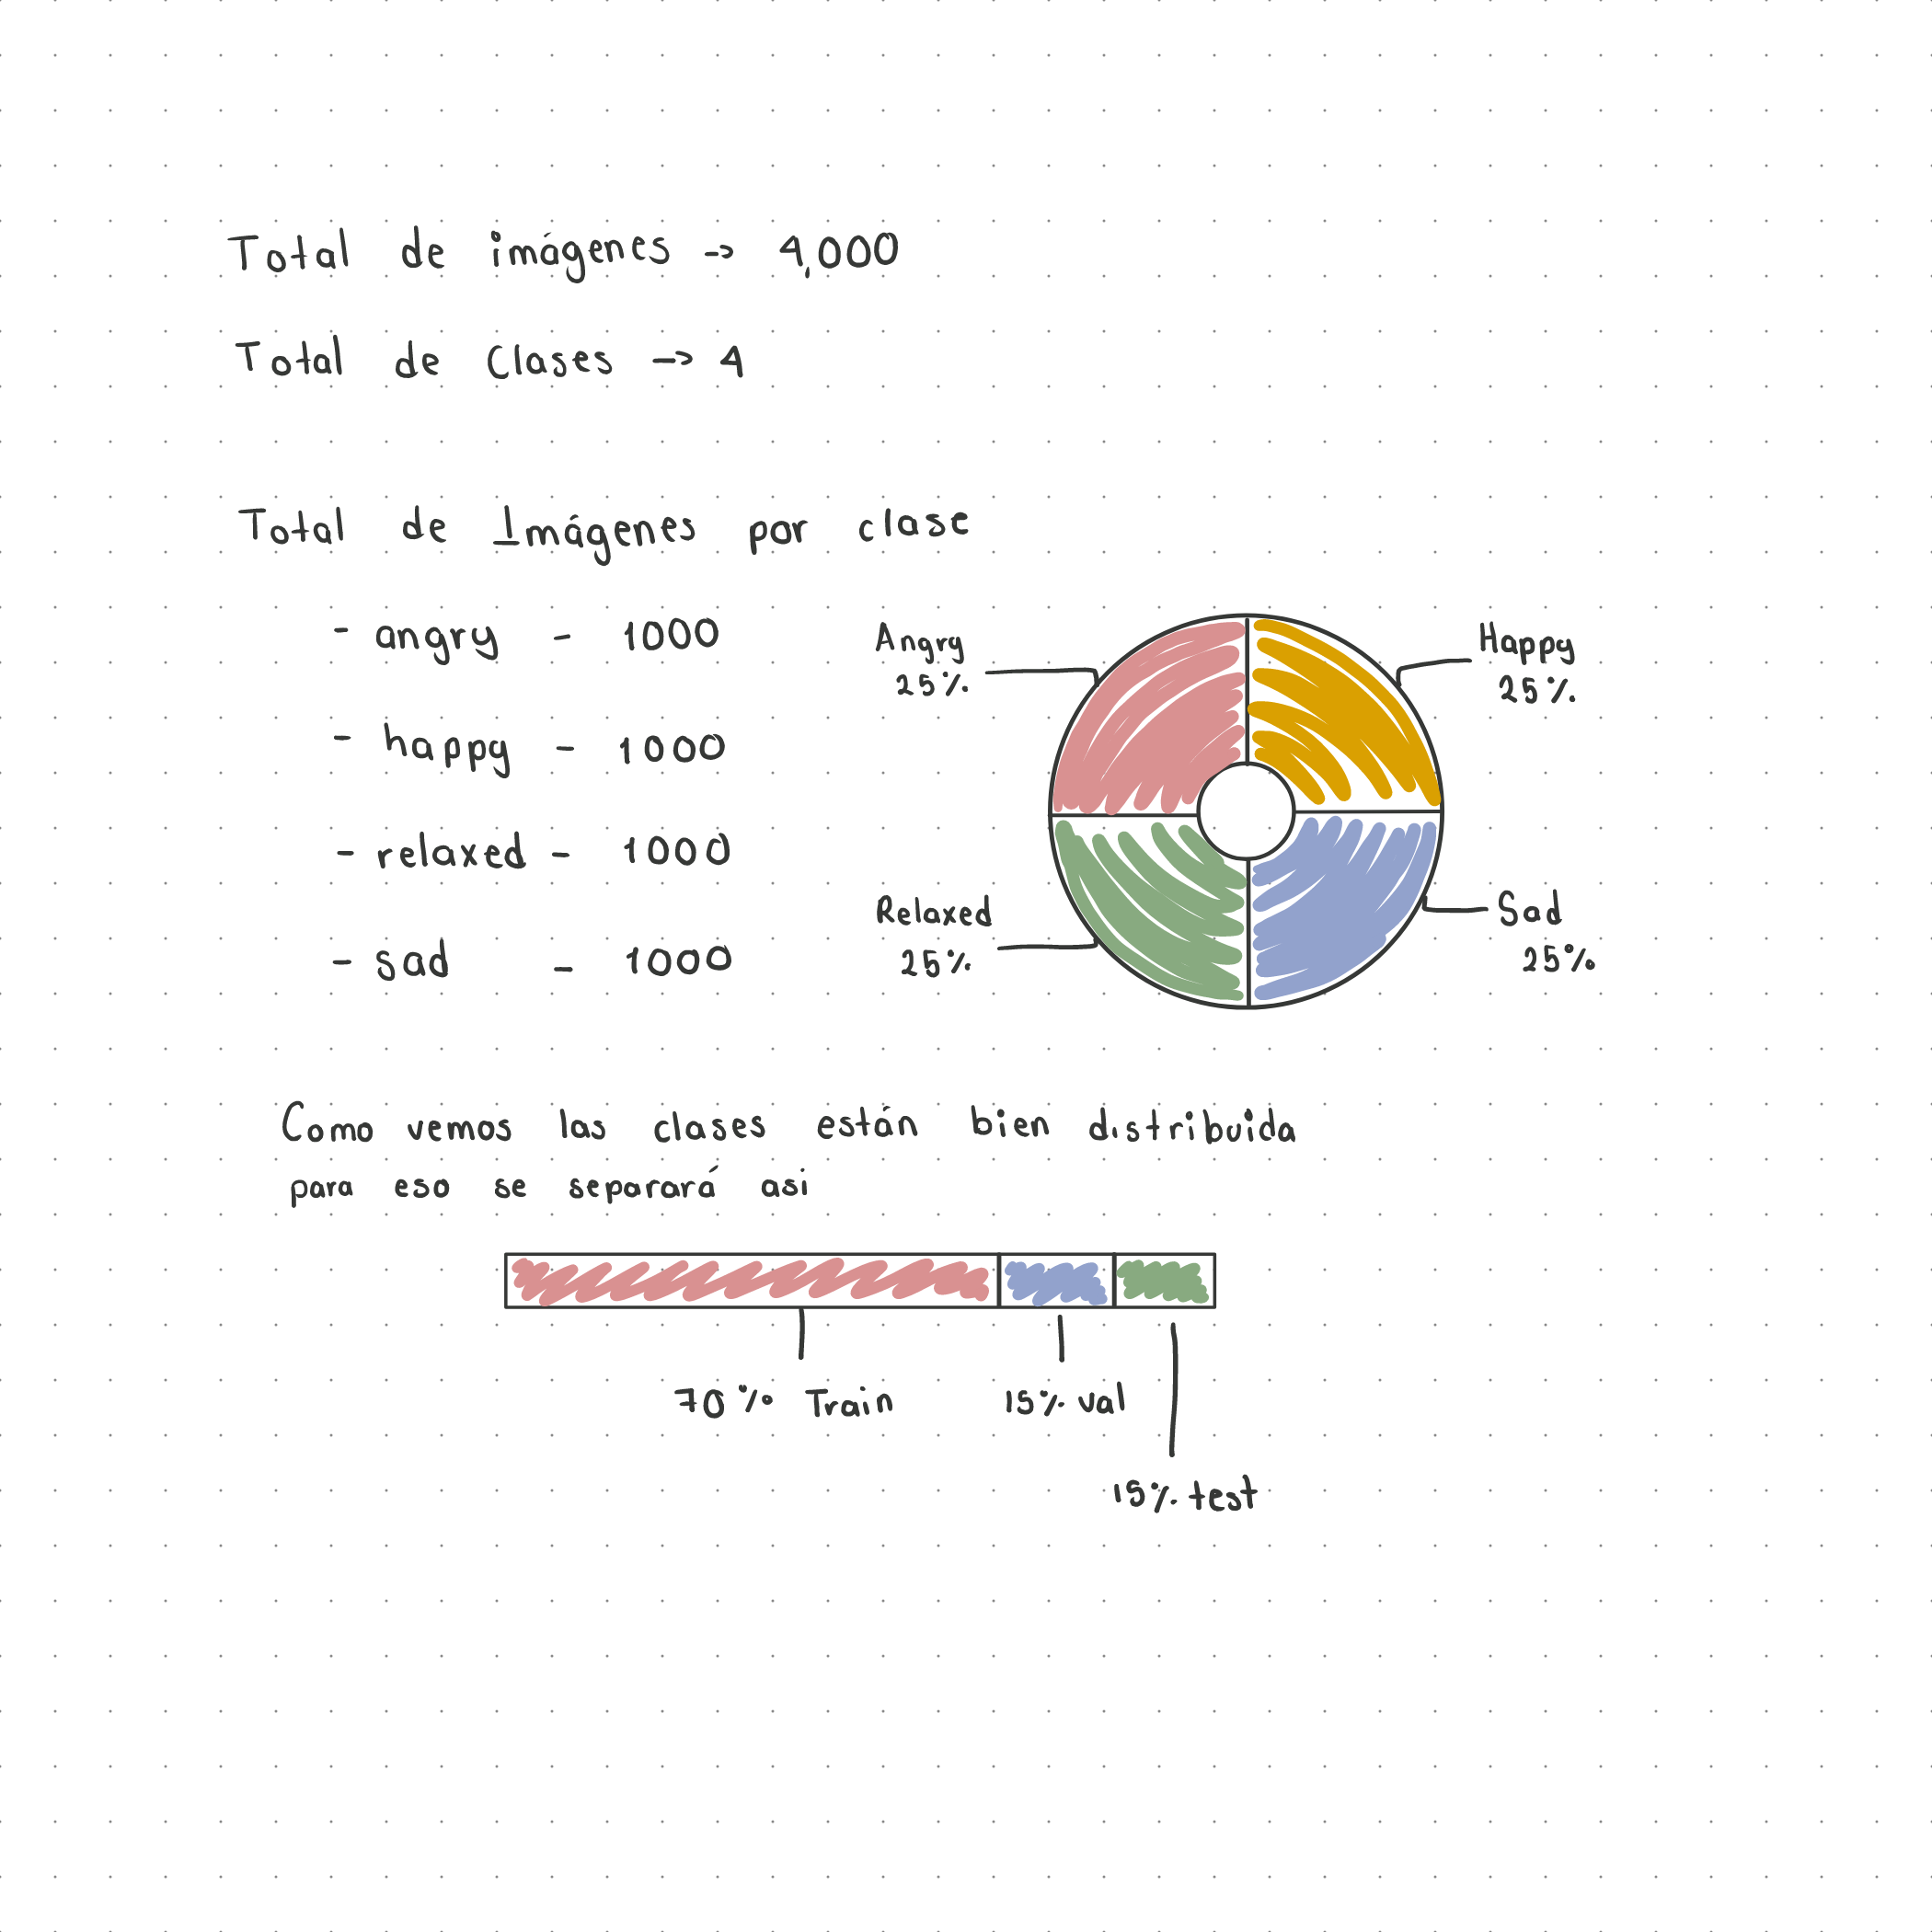

## **4. Separacion de Datasets**

Se separan las imágenes originales y las separa en tres grupos de ,anera aleatorea quedando esta nueva estrucutra de la carpeta
 ```
Split/
    train/
      angry/
      happy/
      relaxed/
      sad/
    validation/
      angry/
      happy/
      relaxed/
      sad/
    test/
      angry/
      happy/
      relaxed/
      sad/
 ```

In [ ]:
origen = Path("Data")
destino = Path("Split")

clases = ["angry", "happy", "relaxed", "sad"]

for clase in clases:
    imgs = list((origen / clase).glob("*"))
    random.shuffle(imgs)

    n = len(imgs)
    train = imgs[:int(n*0.7)]
    val = imgs[int(n*0.7):int(n*0.85)]
    test = imgs[int(n*0.85):]

    for nombre_split, lista in [
        ("train", train),
        ("validation", val),
        ("test", test)
    ]:
        carpeta = destino / nombre_split / clase
        carpeta.mkdir(parents=True, exist_ok=True)

        for img in lista:
            shutil.copy(img, carpeta / img.name)

    print(clase, "listo:", len(train), len(val), len(test))

angry listo: 700 150 150
happy listo: 700 150 150
relaxed listo: 700 150 150
sad listo: 700 150 150


## **5. Preparación y carga de datos para entrenamiento**

Ahora se preparan las imágenes antes de mandarlas al modelo, para eso

se hace un data augmentation, es decir creando variaciones artificiales de las imágenes de entrenamiento, haciendo estas variaciones:

- Movida un poco
- Con zoom
- Más clara
- Más oscura
- Volteada horizontalmente
- Ligeramente deformada

Eso ayuda a que el modelo no memorice las imágenes exactas y aprenda mejor.

Pero además convierte los pixeles de valores de 0 a 255 a valores entre 0 y 1 para ayuda a que el entrenamiento sea más estable.

In [5]:
train_datagen = ImageDataGenerator(
        rescale=1./255,
        width_shift_range=0.15,
        height_shift_range=0.15,
        zoom_range=0.2,
        shear_range=0.12,
        horizontal_flip=True,
        brightness_range=[0.8, 1.2],
        channel_shift_range=0.1,
        fill_mode='nearest'
    )

val_datagen = ImageDataGenerator(
    rescale=1./255
)

Ahora se carga las imágenes desde las carpetas, lee automáticamente las imágenes y detecta las clases por el nombre de las carpetas y hace que todas las imágenes se redimensionen a 150x150, para que el modelo las recibe todas del mismo tamaño.

Tambien se detemrina que el modelo recibe las imágenes en grupos de 32 y se coloca que se trabajará con varias clases, no solo dos.

In [6]:
batch_size = 32

train_generator = train_datagen.flow_from_directory(
    "Split/train",
    target_size=(150, 150),
    batch_size=32,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    "Split/validation",
    target_size=(150, 150),
    batch_size=32,
    class_mode="categorical"
)

Found 2800 images belonging to 4 classes.
Found 600 images belonging to 4 classes.


Aquí se carga un modelo preentrenado llamado VGG16, se usa este modelo pues ya fue entrenado con muchas imágenes de ImageNet, entonces ya sabe detectar cosas básicas.

In [7]:
conv_base= VGG16(weights='imagenet',
								include_top=False,
								input_shape = (150,150,3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Ahora solo se hace la comprobación del proceso que se realizo para ver que este todo definida correctamente

In [8]:
class_names = list(train_generator.class_indices.keys())

images, labels = train_generator.__next__()
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

print("Total imágenes train:", train_generator.n)
print("Total clases:", train_generator.num_classes)
print("Clases:", class_names)

Images shape: (32, 150, 150, 3)
Labels shape: (32, 4)
Total imágenes train: 2800
Total clases: 4
Clases: ['angry', 'happy', 'relaxed', 'sad']


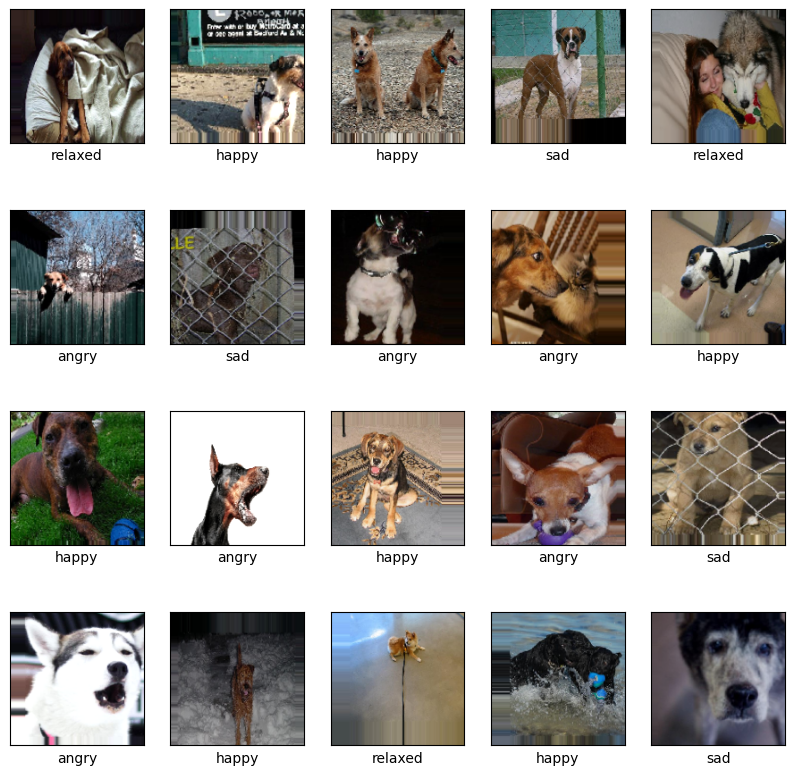

In [9]:
import numpy as np
import matplotlib.pyplot as plt

images, labels = train_generator.__next__()
label_indices = np.argmax(labels, axis=1)

plt.figure(figsize=(10,10))
for i in range(20):
    plt.subplot(4,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(images[i])
    plt.xlabel(class_names[label_indices[i]])
plt.show()

## **6. Primer Modelo**

### **6.1 Generación del primer modelo**

Lo que se hace este modelo es:
1. se coloca que el modelo VGG16 no va a modificar sus pesos durante el entrenamiento
2. Se crea un modelo secuencial, donde las capas van una después de otro
3. se agrega la base preentrenada al modelo
4. Por medio del flaten se aplana la matriz
5. Se agrega una capa intermedia densa con la activación relu que ayuda al modelo a aprender patrones más complejos
6. Se agrega la capa de salida que tiene 4 neuronas porque tiene 4 clases a predecir

In [12]:


conv_base.trainable = False

model = models.Sequential()

model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(4, activation='softmax'))

model.summary()

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=2e-5),
    metrics=['accuracy']
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,813,124 (64.14 MB)

 Trainable params: 2,098,436 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Ahora se prepara el modelo para entrenar

Se da `loss='categorical_crossentropy'` como la función de pérdida

In [13]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2093s 24s/step - accuracy: 0.3729 - loss: 1.3155 - val_accuracy: 0.4800 - val_loss: 1.1906
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 401ms/step - accuracy: 0.4761 - loss: 1.1799 - val_accuracy: 0.5067 - val_loss: 1.1271
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 39s 439ms/step - accuracy: 0.5100 - loss: 1.1249 - val_accuracy: 0.5300 - val_loss: 1.0732
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 36s 404ms/step - accuracy: 0.5475 - loss: 1.0804 - val_accuracy: 0.5417 - val_loss: 1.0399
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 36s 413ms/step - accuracy: 0.5525 - loss: 1.0510 - val_accuracy: 0.5467 - val_loss: 1.0206
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 398ms/step - accuracy: 0.5650 - loss: 1.0281 - val_accuracy: 0.5450 - val_loss: 1.0023
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 37s 412ms/step - accuracy: 0.5746 - loss: 1.0097 - val_accuracy: 0.5650 - val_loss: 0.9905
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 400ms/step - accuracy: 0.5968 - loss: 0.9736 - val_accu

### **6.2 Validación del primer modelo**

El proceso de entrenamiento muestra un comportamiento estable, ya que tanto la precisión de entrenamiento como la de validación aumentan progresivamente, mientras que las pérdidas disminuyen de manera constante. Esto indica que el modelo está aprendiendo patrones relevantes de las imágenes y no presenta señales fuertes de sobreajuste. Sin embargo, la precisión final cercana al 60–63% muestra que el modelo aún tiene margen de mejora, especialmente porque algunas emociones pueden ser visualmente similares y confundirse entre sí.

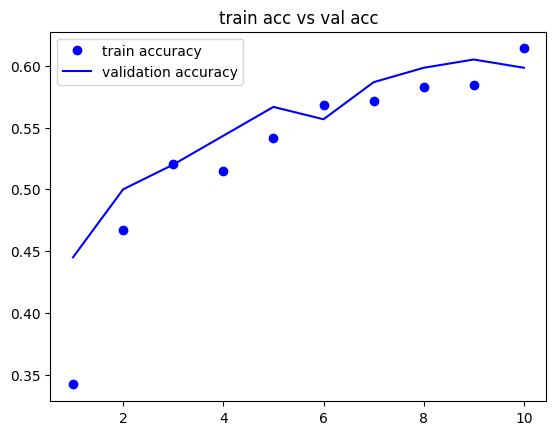

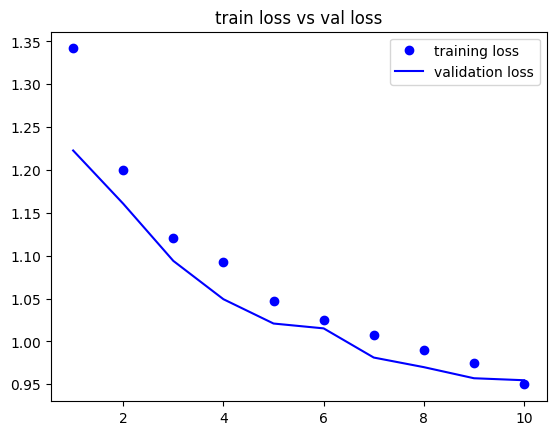

In [26]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs,acc,'bo',label='train accuracy')
plt.plot(epochs,val_acc, 'b', label='validation accuracy')
plt.title('train acc vs val acc')
plt.legend()

plt.figure()

plt.plot(epochs,loss, 'bo', label ='training loss')
plt.plot(epochs,val_loss, 'b', label = 'validation loss')
plt.title('train loss vs val loss')
plt.legend()

plt.show()

Las curvas de precisión y pérdida muestran que el modelo presenta un comportamiento de entrenamiento estable. Tanto la precisión de entrenamiento como la de validación aumentan progresivamente, mientras que sus respectivas funciones de pérdida disminuyen a lo largo de las épocas. Además, las diferencias entre los resultados de entrenamiento y validación se mantienen reducidas.

Este comportamiento indica que no existe evidencia significativa de overfitting, ya que el rendimiento en validación no se deteriora mientras el rendimiento en entrenamiento continúa mejorando. Aunque en las últimas épocas se observa una ligera disminución de la precisión de validación, esta variación es pequeña y no está acompañada por un aumento de la pérdida de validación, por lo que no puede considerarse un caso claro de sobreajuste.

Sin embargo, el modelo alcanza una precisión cercana al 60 % tanto en entrenamiento como en validación. Debido a que ambas métricas permanecen relativamente similares y no llegan a valores elevados, podría existir un cierto grado de underfitting. Esto significa que el modelo generaliza de manera consistente, pero posiblemente no posee la capacidad suficiente, no ha sido entrenado durante el tiempo necesario o requiere una mejor configuración para aprender completamente los patrones presentes en los datos.

En conclusión, el modelo puede clasificarse como ligeramente subajustado, es por ello que se generará otro modelo para eliminar este sobreajuste


## **7. Segundo Modelo**

Para este modelo se hizo referencia a un texto cientifico de calsificación de perros, un modelo muy similar asi que un cambio es al hacer las generaciones de imagnes al usar la función `preprocessing_function=preprocess_input` esta funcion ayudará a que al seleccion preprocesador que se adapte para que funcione mejor. De lo demás sigue siendo similar el funcionamiento



In [14]:
img_size = (224, 224)
batch_size = 32

train_datagen_2 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    shear_range=0.12,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen_2 = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen_2 = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [15]:
train_generator_2 = train_datagen_2.flow_from_directory(
    "Split/train",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

val_generator_2 = val_datagen_2.flow_from_directory(
    "Split/validation",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

Found 2800 images belonging to 4 classes.
Found 600 images belonging to 4 classes.


### **7.1 Generación del segundo modelo**

Para este modelo de carga cargando EfficientNetV2B0, que es una red neuronal convolucional ya entrenada previamente, por lo que nos es muy util pues este modelo ya sabe reconocer patrones visuales generales. De aqui se hace este proceso:
- Se congela la base convolucional, por eso EfficientNet no va a cambiar sus pesos internos
- Se crea un modelo tipo Sequential, haciendo que las capas se van agregando una después de otra, en orden.
- Se coloca EfficientNet como la primera parte del modelo.
- Se toma lo que general el EfficientNet y lo convierte en un vector más paqueño
- Se coloca un capa con 256 neuronas con la activación relu.
- Se apaga aleatoriamente 30% de las neuronas para que no aprenda patrones
- Se coloca una capa densa de 4 neuronas de salida que son las emociones que pudiera tener.

In [16]:
conv_base = EfficientNetV2B0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

conv_base.trainable = False

model_2 = models.Sequential()
model_2.add(conv_base)
model_2.add(layers.GlobalAveragePooling2D())
model_2.add(layers.Dense(256, activation="relu"))
model_2.add(layers.Dropout(0.3))
model_2.add(layers.Dense(4, activation="softmax"))

model_2.compile(
    loss="categorical_crossentropy",
    optimizer=optimizers.RMSprop(learning_rate=2e-5),
    metrics=["accuracy"]
)

model_2.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,248,276 (23.84 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

### **7.2 Entrenamiento del modelo con callbacks**

Para el entrenamiento de este modelo se utilizará diversas callbacks, esto para hacer más eficiente el modelo siendo:
1. EarlyStopping el cual sirve para detener el entrenamiento si el modelo deja de mejorar
2. ModelCheckpoint, este guarda el mejor modelo en un archivo.
3. ReduceLROnPlateau, esto reduce la velocidad de aprendizaje si el modelo se estanca.

Con eso ya se entrena el modelo.

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=6,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_dog_emotion_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7
    )
]

history_2 = model_2.fit(
    train_generator_2,
    epochs=40,
    validation_data=val_generator_2,
    callbacks=callbacks
)

Epoch 1/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 823s 9s/step - accuracy: 0.2693 - loss: 1.4056 - val_accuracy: 0.3367 - val_loss: 1.3357 - learning_rate: 2.0000e-05
Epoch 2/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 54s 616ms/step - accuracy: 0.3579 - loss: 1.3219 - val_accuracy: 0.4217 - val_loss: 1.2680 - learning_rate: 2.0000e-05
Epoch 3/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 54s 613ms/step - accuracy: 0.4071 - loss: 1.2671 - val_accuracy: 0.4817 - val_loss: 1.2148 - learning_rate: 2.0000e-05
Epoch 4/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 54s 608ms/step - accuracy: 0.4604 - loss: 1.2187 - val_accuracy: 0.5200 - val_loss: 1.1706 - learning_rate: 2.0000e-05
Epoch 5/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 54s 615ms/step - accuracy: 0.4879 - loss: 1.1853 - val_accuracy: 0.5517 - val_loss: 1.1341 - learning_rate: 2.0000e-05
Epoch 6/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 53s 605ms/step - accuracy: 0.5079 - loss: 1.1473 - val_accuracy: 0.5667 - val_loss: 1.1031 - learning_rate: 2.0000e-05
Epoch 7/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 55s 616ms/step - accur

### **7.3 Ajuste fino del modelo preentrenado**

Lo que ahora se trata de hacer es usar el modelo cargado previamente EfficientNet para descongelar las útimas 30 capas y con eso permitir que el modelo actue sobre las últimas capas del modelo que son las más importantes pues se basan ya en patrones específicos. Con eso se reecopila el modelo nuevamente ya entrenado

In [18]:
conv_base.trainable = True

for layer in conv_base.layers[:-30]:
    layer.trainable = False

model_2.compile(
    loss="categorical_crossentropy",
    optimizer=optimizers.RMSprop(learning_rate=1e-6),
    metrics=["accuracy"]
)

history_fine = model_2.fit(
    train_generator_2,
    epochs=15,
    validation_data=val_generator_2,
    callbacks=callbacks
)

Epoch 1/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 109s 902ms/step - accuracy: 0.7143 - loss: 0.8024 - val_accuracy: 0.6967 - val_loss: 0.8281 - learning_rate: 1.0000e-06
Epoch 2/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 53s 595ms/step - accuracy: 0.7132 - loss: 0.7990 - val_accuracy: 0.7000 - val_loss: 0.8252 - learning_rate: 1.0000e-06
Epoch 3/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 53s 601ms/step - accuracy: 0.7075 - loss: 0.8045 - val_accuracy: 0.6983 - val_loss: 0.8271 - learning_rate: 1.0000e-06
Epoch 4/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 52s 594ms/step - accuracy: 0.7107 - loss: 0.7914 - val_accuracy: 0.7000 - val_loss: 0.8235 - learning_rate: 3.0000e-07
Epoch 5/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 52s 585ms/step - accuracy: 0.7079 - loss: 0.8015 - val_accuracy: 0.6967 - val_loss: 0.8250 - learning_rate: 3.0000e-07
Epoch 6/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 53s 606ms/step - accuracy: 0.7175 - loss: 0.7955 - val_accuracy: 0.7050 - val_loss: 0.8157 - learning_rate: 3.0000e-07


### **7.4 Validación del modelo**

In [20]:
test_generator = test_datagen_2.flow_from_directory(
    "Split/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 600 images belonging to 4 classes.


In [21]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

test_generator.reset()

predicciones = model_2.predict(test_generator)
y_pred = np.argmax(predicciones, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

print(confusion_matrix(y_true, y_pred))

19/19 ━━━━━━━━━━━━━━━━━━━━ 179s 10s/step
              precision    recall  f1-score   support

       angry       0.67      0.64      0.66       150
       happy       0.61      0.77      0.68       150
     relaxed       0.62      0.62      0.62       150
         sad       0.83      0.65      0.73       150

    accuracy                           0.67       600
   macro avg       0.68      0.67      0.67       600
weighted avg       0.68      0.67      0.67       600

[[ 96  30  16   8]
 [ 14 115  18   3]
 [ 13  35  93   9]
 [ 20   9  23  98]]


## **8. Tercer Modelo**

Para este modelo se hizo referencia a un texto cientifico de calsificación de perros y se uso el modelo anterior ero en este caso se agrego una capa densa más pues en el entrenamiento se noto que hay mejoras entre más epocas asi que se quiso probar si hay mejoras con más capas densas

### **8.1 Generación del tercer modelo**

Para este modelo de carga cargando EfficientNetV2B0, que es una red neuronal convolucional ya entrenada previamente, por lo que nos es muy util pues este modelo ya sabe reconocer patrones visuales generales. De aqui se hace este proceso:
- Se congela la base convolucional, por eso EfficientNet no va a cambiar sus pesos internos
- Se crea un modelo tipo Sequential, haciendo que las capas se van agregando una después de otra, en orden.
- Se coloca EfficientNet como la primera parte del modelo.
- Se toma lo que general el EfficientNet y lo convierte en un vector más paqueño
- Se coloca un capa con 256 neuronas con la activación relu.
- Se apaga aleatoriamente 40% de las neuronas para que no aprenda patrones
- Se coloca un capa con 128 neuronas con la activación relu.
- Se apaga aleatoriamente 30% de las neuronas para que no aprenda patrones
- Se coloca una capa densa de 4 neuronas de salida que son las emociones que pudiera tener.

In [ ]:
conv_base = EfficientNetV2B0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

conv_base.trainable = False

model_3 = models.Sequential()
model_3.add(conv_base)
model_3.add(layers.GlobalAveragePooling2D())
model_3.add(layers.Dense(256, activation="relu"))
model_3.add(layers.Dropout(0.4))
model_3.add(layers.Dense(128))
model_3.add(layers.Dropout(0.3))
model_3.add(layers.Dense(4, activation="softmax"))

model_3.compile(
    loss="categorical_crossentropy",
    optimizer=optimizers.RMSprop(learning_rate=2e-5),
    metrics=["accuracy"]
)

model_3.summary()

### **8.2 Entrenamiento del modelo con callbacks**

Para el entrenamiento de este modelo se utilizará diversas callbacks, esto para hacer más eficiente el modelo siendo:
1. EarlyStopping el cual sirve para detener el entrenamiento si el modelo deja de mejorar
2. ModelCheckpoint, este guarda el mejor modelo en un archivo.
3. ReduceLROnPlateau, esto reduce la velocidad de aprendizaje si el modelo se estanca.

Con eso ya se entrena el modelo.

In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=6,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_dog_emotion_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7
    )
]

history_3 = model_3.fit(
    train_generator_2,
    epochs=50,
    validation_data=val_generator_2,
    callbacks=callbacks
)

### **8.3 Validación del modelo**

In [ ]:
test_generator.reset()

predicciones = model_3.predict(test_generator)
y_pred = np.argmax(predicciones, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

print(confusion_matrix(y_true, y_pred))

Este modelo tiene un 72% de precision, por lo que se puede decir que es un modelo mejor de las anteriores modelos

In [ ]:
model_3.save("best_dog_emotion_model_final_2.keras")